In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

In [3]:
data = load_breast_cancer()
X, y = data.data, 1 - data.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=1
)

In [5]:
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000))

In [9]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=10,
    n_jobs=-1)

In [10]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

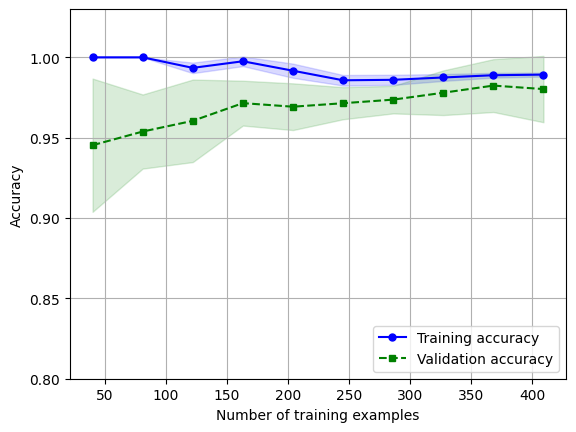

In [17]:
fig, ax = plt.subplots()

ax.plot(train_sizes, train_mean, color='blue', marker='o',
        markersize=5, label='Training accuracy')
ax.fill_between(train_sizes, train_mean + train_std,
                train_mean - train_std, alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean, color='green', linestyle='--',
        marker='s', markersize=5, label='Validation accuracy')
ax.fill_between(train_sizes, test_mean + test_std,
                test_mean - test_std, alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Number of training examples')
ax.set_ylabel('Accuracy')
ax.set_ylim([0.8, 1.03])
ax.legend(loc='lower right')
plt.show()